<a href="https://colab.research.google.com/github/shauryasachdev/Vizuara_CV/blob/main/Transfer_and_Differential_Learning_Rate_Deep_NN_for_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ────────────────────────────────────────────────────────────────
# Standard library & OS / file handling
import os
import pathlib
import random
import glob

# Image & display utilities
from PIL import Image
import IPython.display as display
import matplotlib.pyplot as plt   # usually preferred over pylab

# Data science & numerics
import numpy as np

# Weights & Biases ────────────────────────────────────────────────
import wandb
from wandb.integration.keras import WandbMetricsLogger   # batch-level logging

# TensorFlow / Keras ──────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    MaxPooling2D,
    Softmax,
    Input
)
import tensorflow_hub as hub

In [ ]:
sweep_config = {

    'method' : 'grid',
    'metric' : {
        'name': 'valid_accuray',
        'goal': 'maximize'
              },
    'parameters': {
        'batch_size': {'values': [8]},
        'learning_rate': {'values': [0.0001]},
    'hidden_nodes' : {'values' : [128]},
    'img_size' : {'values' : [128]},
     'epochs' :{'values' : [10]}
                  }

    }

sweep_id = wandb.sweep(sweep_config, project="5-flowers-transfer-v8")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Create sweep with ID: wjm2nrcm
Sweep URL: https://wandb.ai/shauryasachdev/5-flowers-transfer-v8/sweeps/wjm2nrcm


In [ ]:
from google.colab import drive
drive.mount('/content/drive')  # Mounts Drive at /content/drive/

# Set your desired Drive path (creates folder if it doesn't exist)
drive_path = '/content/drive/MyDrive/Colab Notebooks/flower_dataset/'

# Download and extract directly to the Drive path
# archive = tf.keras.utils.get_file(
#    'flower_photos.tgz',
#    'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz',
#    cache_dir=drive_path,  # Saves here instead of local cache
#    extract=True
#)

# Your exact path as Path object
data_dir = pathlib.Path('/content/drive/MyDrive/Colab Notebooks/flower_dataset/datasets/flower_photos_extracted/flower_photos')

# Verify
image_count = len(list(data_dir.glob('*/*.jpg')))
print("There are", image_count, "images.")  # Should be 3670

CLASS_NAMES = np.array(
    [item.name for item in data_dir.glob('*') if item.name != "LICENSE.txt" and item.is_dir()]
)
print("These are the available classes:", CLASS_NAMES)

Mounted at /content/drive
There are 3670 images.
These are the available classes: ['dandelion' 'daisy' 'tulips' 'roses' 'sunflowers']


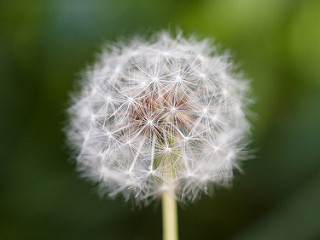

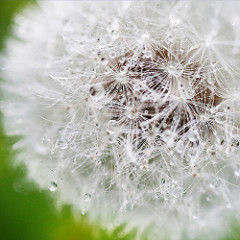

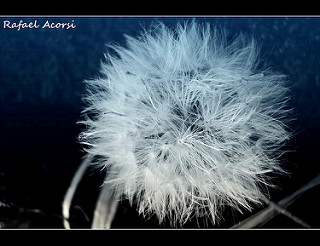

In [ ]:
roses = list(data_dir.glob('dandelion/*'))

for image_path in roses[:3]:
    display.display(Image.open(str(image_path)))

In [ ]:
# Your Drive path to the flower_photos folder with class subdirs
data_dir = pathlib.Path('/content/drive/MyDrive/Colab Notebooks/flower_dataset/datasets/flower_photos_extracted/flower_photos')

# Collect all image paths and labels from Drive (local paths)
all_images = []
for class_name in CLASS_NAMES:
    class_dir = data_dir / class_name
    images = glob.glob(str(class_dir / '*.jpg'))
    for img in images:
        all_images.append(f"{img},{class_name}")

# Shuffle and split into train/eval (80/20)
random.shuffle(all_images)
num_total = len(all_images)
num_train = int(0.8 * num_total)
train_lines = all_images[:num_train]
eval_lines = all_images[num_train:]

# Write CSVs to Drive (using data_dir as base)
train_csv_path = os.path.join(str(data_dir), 'train_set.csv')
eval_csv_path = os.path.join(str(data_dir), 'eval_set.csv')

with open(train_csv_path, 'w') as f:
    f.write('\n'.join(train_lines))
with open(eval_csv_path, 'w') as f:
    f.write('\n'.join(eval_lines))

# Verify: Print first 5 lines of train CSV using shell (with quoted path to avoid syntax errors)
!head -5 "{train_csv_path}"

/content/drive/MyDrive/Colab Notebooks/flower_dataset/datasets/flower_photos_extracted/flower_photos/dandelion/18243351371_5fda92ac0a_n.jpg,dandelion
/content/drive/MyDrive/Colab Notebooks/flower_dataset/datasets/flower_photos_extracted/flower_photos/roses/7251352826_69b62cba2c_m.jpg,roses
/content/drive/MyDrive/Colab Notebooks/flower_dataset/datasets/flower_photos_extracted/flower_photos/tulips/3626132563_d955973447_n.jpg,tulips
/content/drive/MyDrive/Colab Notebooks/flower_dataset/datasets/flower_photos_extracted/flower_photos/daisy/2479956481_8d1a9699be_n.jpg,daisy
/content/drive/MyDrive/Colab Notebooks/flower_dataset/datasets/flower_photos_extracted/flower_photos/dandelion/11775820493_10fedf4bff_n.jpg,dandelion


In [ ]:
def train():
  with wandb.init() as run:
    config = wandb.config

    Img_Height = config.img_size
    Img_Width = config.img_size
    Img_Channels = 3


    def read_and_decode(filename, resize_dims):
      # Read the raw file
      img_bytes = tf.io.read_file(filename)
      # Decode the image data
      img = tf.image.decode_jpeg(img_bytes, channels=Img_Channels)
      # Convert the pixel values to float in [0,1]
      img = tf.image.convert_image_dtype(img, tf.float32)
      # Resize the image to desired dimensions
      img = tf.image.resize(img, resize_dims)
      return img

    def parse_csvline(csv_line):
      # record_defaults specify the data types for each column
      record_default = ["", ""]
      filename, label_string = tf.io.decode_csv(csv_line, record_default)

      # Load the image
      img = read_and_decode(filename, [Img_Height, Img_Width])

      # Conver label string to integer based on the Class_Names index
      label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))
      return img, label

    train_dataset = (
      tf.data.TextLineDataset(train_csv_path)
      .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
      .batch(config.batch_size)
      .prefetch(tf.data.AUTOTUNE)
      )

    eval_dataset = (
      tf.data.TextLineDataset(eval_csv_path)
      .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
      .batch(config.batch_size)
      .prefetch(tf.data.AUTOTUNE)
      )

    regularizer = tf.keras.regularizers.l1_l2(0,0.01)

    # Define Exponential Learning Rate
    initial_learning_rate = config.learning_rate
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=initial_learning_rate,
        decay_steps = 100,
        decay_rate = 0.96,
        staircase = True
    )

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(128, 128, 3),
        include_top=False, # Remove Classification head
        weights='imagenet' # Load weights trained on ImageNet
    )

    base_model.trainable = True

    model = tf.keras.Sequential([
      base_model,
      tf.keras.layers.GlobalAveragePooling2D(),
      tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
    ])

    model.compile(
      optimizer =tf.keras.optimizers.Adam(learning_rate=lr_schedule),
      loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
      metrics=["accuracy"]
    )

    model.summary()

    callbacks = [
      WandbMetricsLogger(log_freq=5),
      tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                       restore_best_weights=True)
    ]

    model.fit(
      train_dataset,
      validation_data = eval_dataset,
      epochs = config.epochs,
      callbacks = callbacks
  )

In [ ]:
wandb.agent(sweep_id, function=train)

wandb: Agent Starting Run: 46gkhtfl with config:
wandb: 	batch_size: 8
wandb: 	epochs: 10
wandb: 	hidden_nodes: 128
wandb: 	img_size: 128
wandb: 	learning_rate: 0.0001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: shauryasachdev to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

...

Epoch 1/10
    367/Unknown 430s 1s/step - accuracy: 0.6636 - loss: 0.9048

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


367/367 ━━━━━━━━━━━━━━━━━━━━ 526s 1s/step - accuracy: 0.6639 - loss: 0.9041 - val_accuracy: 0.7847 - val_loss: 0.6842
Epoch 2/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 241s 656ms/step - accuracy: 0.9650 - loss: 0.1307 - val_accuracy: 0.8515 - val_loss: 0.4527
Epoch 3/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 323s 880ms/step - accuracy: 1.0000 - loss: 0.0157 - val_accuracy: 0.8842 - val_loss: 0.3698
Epoch 4/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 257s 700ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.8896 - val_loss: 0.3441
Epoch 5/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 261s 712ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.8924 - val_loss: 0.3386
Epoch 6/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 273s 742ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.8951 - val_loss: 0.3410
Epoch 7/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 271s 738ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8924 - val_loss: 0.3465
Epoch 8/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 263s 717ms/step - accuracy: 1.0000 - loss: 0.0019 

batch/accuracy,▁▃▄▅▅▅▇▇████████████████████████████████
batch/batch_step,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
batch/learning_rate,██▇▇▇▆▆▆▆▆▆▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
batch/loss,█▆▅▅▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁███████
epoch/epoch,▁▂▃▄▅▆▇█
epoch/learning_rate,█▆▅▄▃▂▂▁
epoch/loss,█▂▁▁▁▁▁▁
epoch/val_accuracy,▁▅▇█████
epoch/val_loss,█▃▂▁▁▁▁▁
batch/accuracy,1


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


In [ ]:
 import math

for images, labels in eval_dataset.take(1):
  batch_predictions = model.predict(images)
  predicted_indices = np.argmax(batch_predictions, axis = 1)

  num_images = images.shape[0]
  num_cols = 4
  num_rows = math.ceil(num_images / num_cols)

  plt.figure(figsize=(12,3*num_rows))

  for i in range(num_images):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(images[i].numpy())
    plt.axis("off")

    pred_class = CLASS_NAMES[predicted_indices[i]]
    actual_class = CLASS_NAMES[labels[i].numpy()]

    plt.title(f"Predicted: {pred_class}\nActual: {actual_class}", fontsize = 10)

  plt.tight_layout()
  plt.show